# TP4 AA1

# Alumno: Moises Lobayza

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

* En el foro destinado a la tarea debe postear al menos tres veces:
  - La primera vez para indicar el dataset elegido
  - Una segunda vez para postear su entrega
  - Una tercera vez para brindar feedback a alguien más en el foro.
  - Puede comentar más de un posteo de sus compañeros siempre y cuando el intercambio sea respetuoso y fructífero.
* Deben postear como solución un enlace a su notebook colab público y también un enlace al mismo notebook alojado en su repositorio GitHub.
* Debe sumar el enlace a un video donde muestre su solución y explique lo realizado. Duración máxima: 5 - 10 minutos. Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como privado o Unlisted.
* Enlaces no accesibles o enlaces erróneos es igual a determinar que la tarea no ha sido entregada. Corrobore la viabilidad de los enlaces que postea.


#**Tarea: Aplicación de Regresión Lineal y Análisis de Importancia de Variables**  
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=  
   - Requisitos:  
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).  
     - Idealmente, que las features tengan distintas escalas o unidades ( no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

# Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

#  Elección del dataset

Elijo el dataset **Concrete Compressive Strength del UCI Machine Learning Repository**. El objetivo será predecir la resistencia a la compresión del hormigón a partir de variables numéricas como cemento, agua, agregados, aditivos y edad de la mezcla. Lo selecciono porque cumple con los requisitos del trabajo: posee varias variables numéricas continuas y un target cuantitativo para un problema de regresión.

# Carga de datos

In [2]:
file_id = "1HFMyTMee9FYMPVlzQYG1Nm46QOOVtAlF"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

datos = pd.read_excel(url)
display(datos.head())

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


# Renombramos para comodidad al trabajar.

In [3]:
datos.columns = [
    "cemento",
    "escoria_alto_horno",
    "ceniza_volante",
    "agua",
    "superplastificante",
    "agregado_grueso",
    "agregado_fino",
    "edad_dias",
    "resistencia_compresion"
]

display(datos.head())

,cemento,escoria_alto_horno,ceniza_volante,agua,superplastificante,agregado_grueso,agregado_fino,edad_dias,resistencia_compresion
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


# Definimos variable objetivo

In [4]:
target = "resistencia_compresion"


## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?  


## Resolución:

# Información general del dataset

In [5]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cemento                 1030 non-null   float64
 1   escoria_alto_horno      1030 non-null   float64
 2   ceniza_volante          1030 non-null   float64
 3   agua                    1030 non-null   float64
 4   superplastificante      1030 non-null   float64
 5   agregado_grueso         1030 non-null   float64
 6   agregado_fino           1030 non-null   float64
 7   edad_dias               1030 non-null   int64  
 8   resistencia_compresion  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [6]:
datos.shape


(1030, 9)

In [7]:
datos.isnull().sum()

,0
cemento,0
escoria_alto_horno,0
ceniza_volante,0
agua,0
superplastificante,0
agregado_grueso,0
agregado_fino,0
edad_dias,0
resistencia_compresion,0


**El dataset contiene 1030 registros y 9 columnas numéricas. No se observan valores nulos, por lo que no es necesario aplicar imputación de datos.**

# Estadísticas descriptivas

In [8]:
datos.describe().T

,count,mean,std,min,25%,50%,75%,max
cemento,1030.0,281.165631,104.507142,102.000000,192.375000,272.900000,350.000000,540.000000
escoria_alto_horno,1030.0,73.895485,86.279104,0.000000,0.000000,22.000000,142.950000,359.400000
ceniza_volante,1030.0,54.187136,63.996469,0.000000,0.000000,0.000000,118.270000,200.100000
agua,1030.0,181.566359,21.355567,121.750000,164.900000,185.000000,192.000000,247.000000
superplastificante,1030.0,6.203112,5.973492,0.000000,0.000000,6.350000,10.160000,32.200000
agregado_grueso,1030.0,972.918592,77.753818,801.000000,932.000000,968.000000,1029.400000,1145.000000
agregado_fino,1030.0,773.578883,80.175427,594.000000,730.950000,779.510000,824.000000,992.600000
edad_dias,1030.0,45.662136,63.169912,1.000000,7.000000,28.000000,56.000000,365.000000
resistencia_compresion,1030.0,35.817836,16.705679,2.331808,23.707115,34.442774,46.136287,82.599225


**Las variables presentan escalas distintas. Por ejemplo, los agregados grueso y fino tienen valores cercanos a cientos de kg/m³, mientras que el superplastificante tiene valores mucho menores. La variable objetivo, resistencia a la compresión, tiene una media aproximada de 35.8 MPa y valores entre 2.3 y 82.6 MPa.**

# Algunos gráficos interesantes para complementar el EDA

# Histogramas para ver distribución

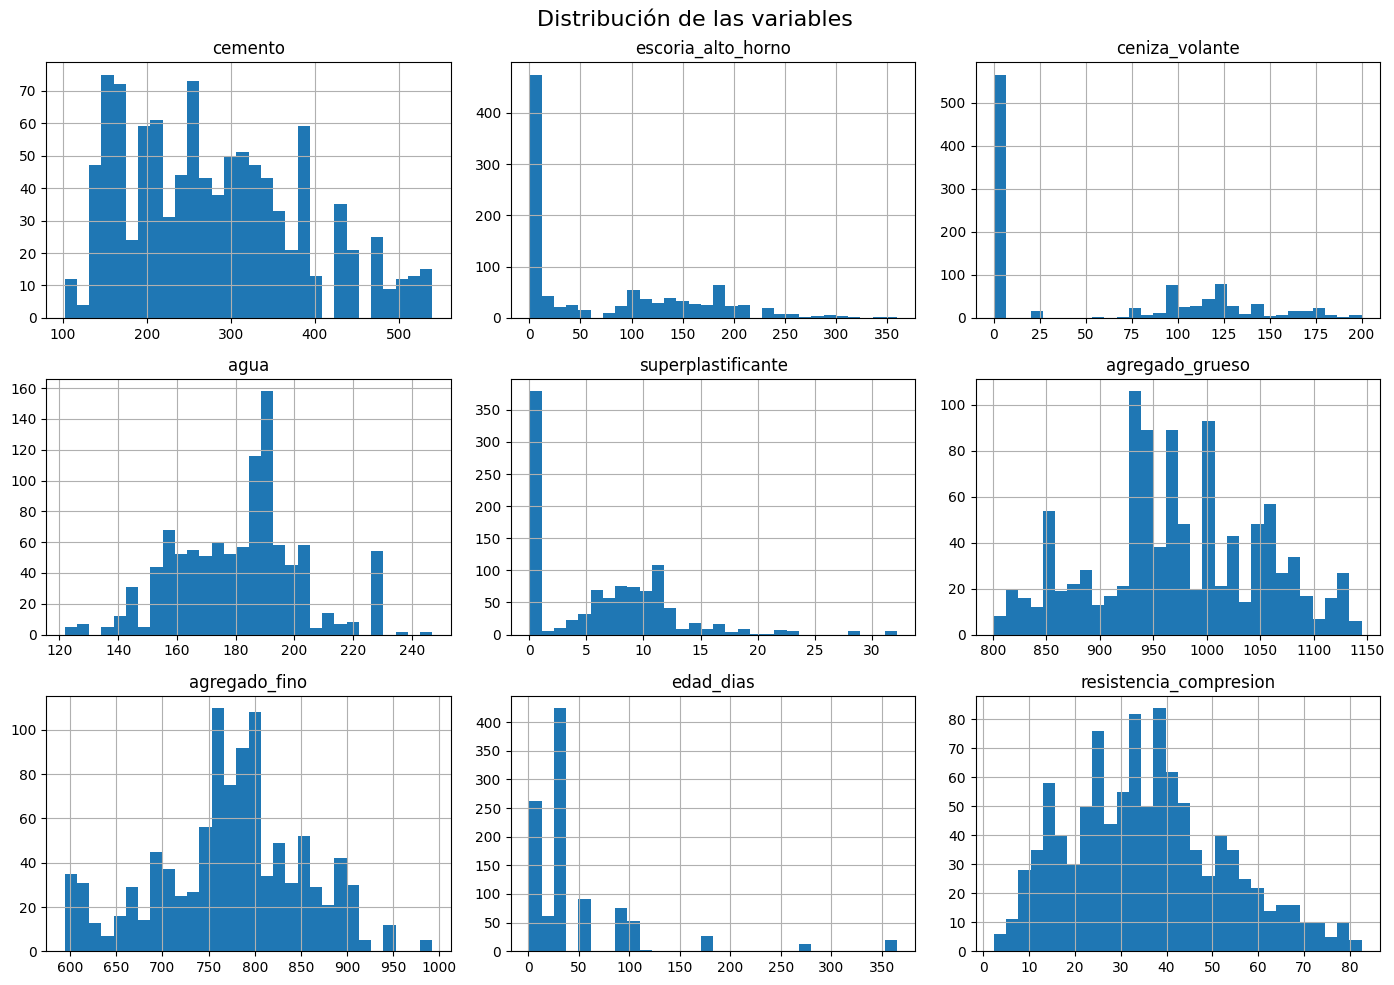

In [9]:
datos.hist(figsize=(14, 10), bins=30)
plt.suptitle("Distribución de las variables", fontsize=16)
plt.tight_layout()
plt.show()

**Los histogramas muestran que las variables tienen distribuciones diferentes. Algunas, como escoria_alto_horno, ceniza_volante y superplastificante, presentan muchos valores en cero, lo que indica que esos componentes no siempre se usan en las mezclas. La variable resistencia_compresion se concentra principalmente en valores intermedios, aunque presenta cierta dispersión.**

# Boxplots para ver outliers

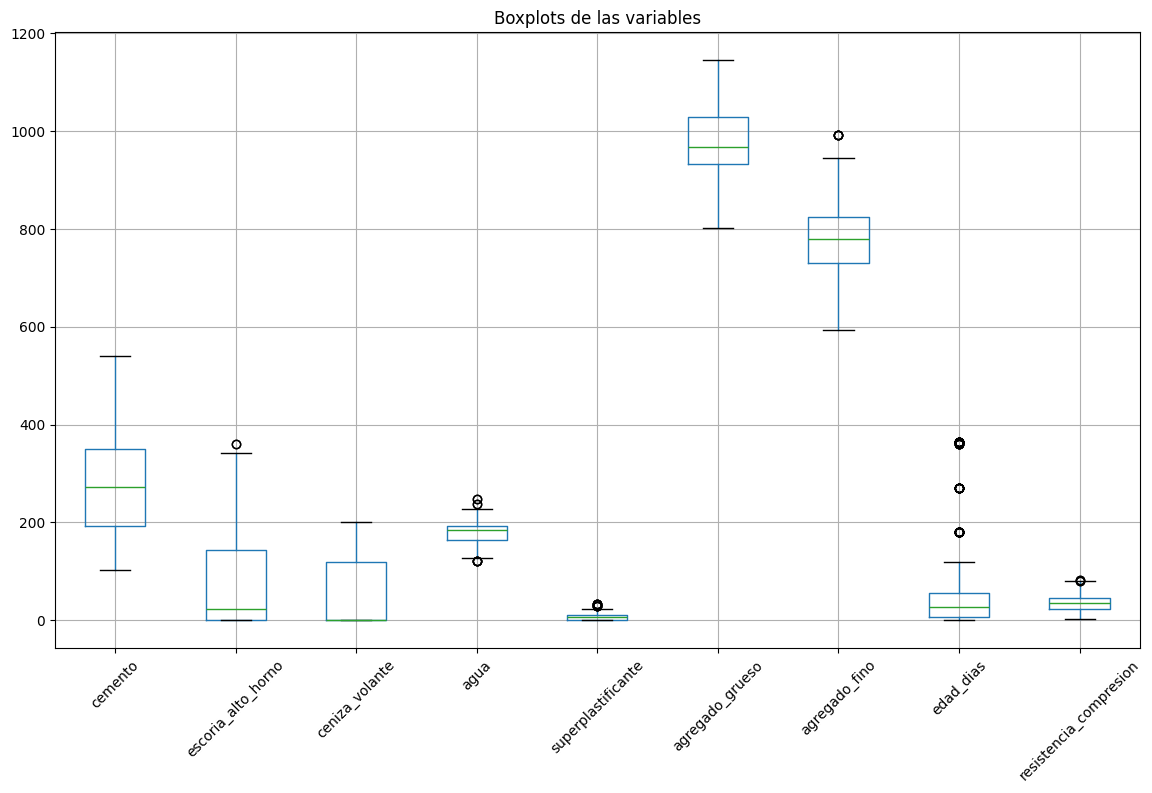

In [10]:
plt.figure(figsize=(14, 8))
datos.boxplot(rot=45)
plt.title("Boxplots de las variables")
plt.show()

**Los boxplots permiten observar posibles valores atípicos en variables como agua, superplastificante, edad_dias, agregado_fino y resistencia_compresion. Sin embargo, estos valores no necesariamente son errores, ya que pueden representar mezclas reales de hormigón con composiciones o edades diferentes.**

# Relación entre features y target

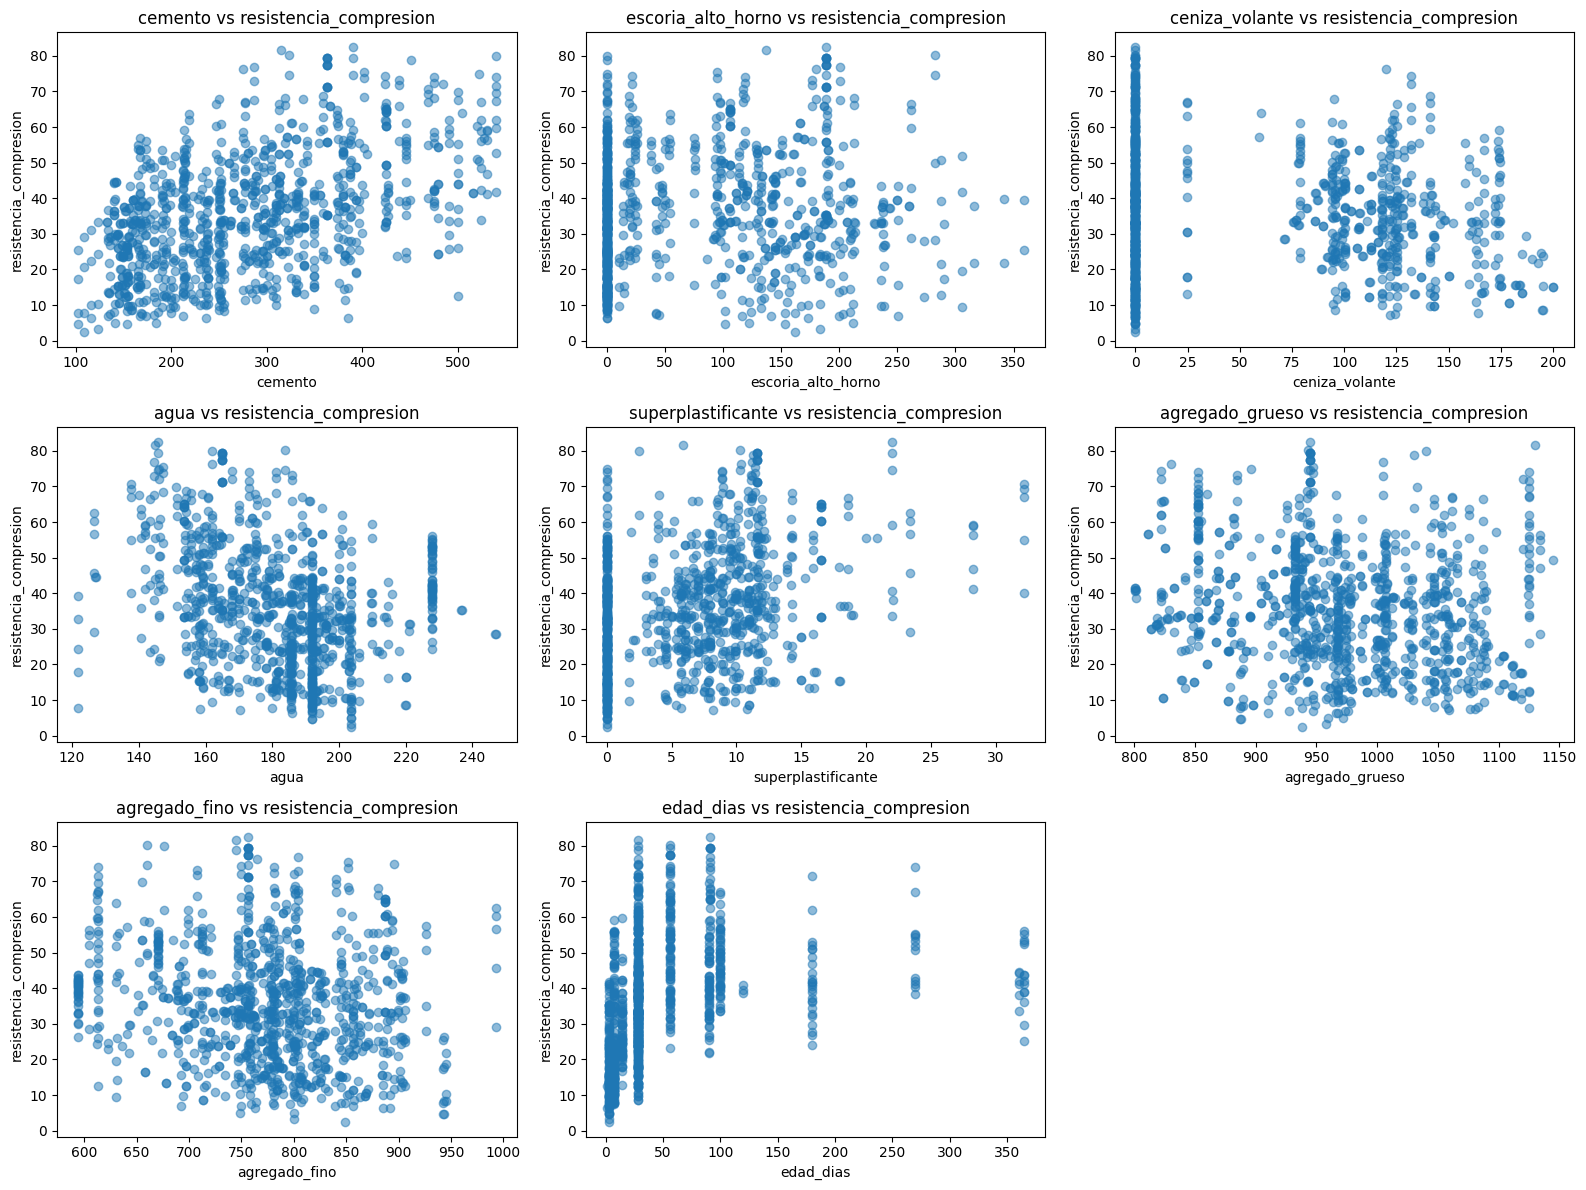

In [11]:
target = "resistencia_compresion"

features = [col for col in datos.columns if col != target]

plt.figure(figsize=(16, 12))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    plt.scatter(datos[col], datos[target], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f"{col} vs {target}")

plt.tight_layout()
plt.show()

En los scatterplots se observa que cemento tiene una relación positiva con la resistencia a la compresión: a mayor cantidad de cemento, tiende a aumentar la resistencia.

La variable agua muestra una relación negativa: mayores cantidades de agua parecen asociarse con menor resistencia.

Superplastificante y edad_dias también muestran cierta relación positiva, aunque no perfectamente lineal. En edad se ven grupos verticales porque los valores están concentrados en días específicos.

Las variables escoria_alto_horno, ceniza_volante, agregado_grueso y agregado_fino no muestran una relación lineal clara con el target. En general, las relaciones preliminares más importantes parecen estar en cemento, agua, superplastificante y edad_dias.

# Correlaciones con el target

In [12]:
correlaciones = datos.corr(numeric_only=True)[target].sort_values(ascending=False)
correlaciones

,resistencia_compresion
resistencia_compresion,1.000000
cemento,0.497833
superplastificante,0.366102
edad_dias,0.328877
escoria_alto_horno,0.134824
ceniza_volante,-0.105753
agregado_grueso,-0.164928
agregado_fino,-0.167249
agua,-0.289613


La variable con mayor correlación positiva con la resistencia a la compresión es cemento (0.49), lo que indica que al aumentar la cantidad de cemento tiende a aumentar la resistencia.

También se observan correlaciones positivas moderadas con superplastificante (0.36) y edad_dias (0.32). Esto coincide con lo visto en los gráficos de dispersión.

La variable agua presenta la correlación negativa más marcada (-0.28), indicando que mayores cantidades de agua tienden a asociarse con menor resistencia.

Las variables escoria_alto_horno, ceniza_volante, agregado_grueso y agregado_fino tienen correlaciones bajas, por lo que no muestran una relación lineal fuerte con el target.

# Conclusión EDA

A partir del **análisis exploratorio**, se observa que el dataset es adecuado para un problema de **regresión**, ya que todas las variables son numéricas y la variable objetivo, resistencia_compresion, es continua.

**Las variables presentan escalas diferentes y distribuciones variadas, por lo que será conveniente aplicar algún tipo de escalamiento antes del modelado**. También se detectan posibles valores atípicos, especialmente en edad_dias, agua, superplastificante y resistencia_compresion, aunque no necesariamente representan errores, sino posibles casos reales de distintas mezclas de hormigón.

En cuanto a las relaciones lineales preliminares, las variables más asociadas con la resistencia son cemento, superplastificante y edad_dias, con correlaciones positivas. Por otro lado, agua muestra una relación negativa con el target. Las demás variables presentan relaciones lineales más débiles.

**En general, el análisis sugiere que existe información útil en las variables predictoras para intentar modelar la resistencia a la compresión mediante regresión lineal.**

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.  
   - Dividan en train/test (70-30 o 80-20).  

## Resolución:

# Separar features y target

In [13]:
target = "resistencia_compresion"

X = datos.drop(columns=[target])
y = datos[target]

print("Features:", X.columns.tolist())
print("Target:", target)

Features: ['cemento', 'escoria_alto_horno', 'ceniza_volante', 'agua', 'superplastificante', 'agregado_grueso', 'agregado_fino', 'edad_dias']
Target: resistencia_compresion


**Se separaron las variables predictoras de la variable objetivo. La variable objetivo es resistencia_compresion, mientras que el resto de las columnas se utilizarán como features.**

# Revisar valores nulos

In [14]:
datos.isnull().sum()

,0
cemento,0
escoria_alto_horno,0
ceniza_volante,0
agua,0
superplastificante,0
agregado_grueso,0
agregado_fino,0
edad_dias,0
resistencia_compresion,0


**No se observan valores nulos en el dataset, por lo tanto no fue necesario eliminar registros ni aplicar imputación.**

# Revisar variables categóricas

In [15]:
datos.dtypes

,0
cemento,float64
escoria_alto_horno,float64
ceniza_volante,float64
agua,float64
superplastificante,float64
agregado_grueso,float64
agregado_fino,float64
edad_dias,int64
resistencia_compresion,float64


**Todas las variables del dataset son numéricas. Por este motivo, no fue necesario aplicar codificación de variables categóricas como One Hot Encoding o Label Encoding.**

# Decisión sobre outliers

In [16]:
datos.describe().T

,count,mean,std,min,25%,50%,75%,max
cemento,1030.0,281.165631,104.507142,102.000000,192.375000,272.900000,350.000000,540.000000
escoria_alto_horno,1030.0,73.895485,86.279104,0.000000,0.000000,22.000000,142.950000,359.400000
ceniza_volante,1030.0,54.187136,63.996469,0.000000,0.000000,0.000000,118.270000,200.100000
agua,1030.0,181.566359,21.355567,121.750000,164.900000,185.000000,192.000000,247.000000
superplastificante,1030.0,6.203112,5.973492,0.000000,0.000000,6.350000,10.160000,32.200000
agregado_grueso,1030.0,972.918592,77.753818,801.000000,932.000000,968.000000,1029.400000,1145.000000
agregado_fino,1030.0,773.578883,80.175427,594.000000,730.950000,779.510000,824.000000,992.600000
edad_dias,1030.0,45.662136,63.169912,1.000000,7.000000,28.000000,56.000000,365.000000
resistencia_compresion,1030.0,35.817836,16.705679,2.331808,23.707115,34.442774,46.136287,82.599225


**Se detectaron posibles valores atípicos en algunas variables, como edad_dias, agua, superplastificante y resistencia_compresion. Sin embargo, no se eliminaron porque pueden representar casos reales de distintas formulaciones y edades del hormigón. Además, eliminarlos sin una justificación técnica podría hacer perder información útil para el modelo.**

# Features descartadas

**No se descartaron features en esta etapa, ya que todas las variables son numéricas y pueden aportar información al modelo. Aunque algunas variables presentan baja correlación lineal con el target, se conservaron para evaluar su aporte dentro del modelo de regresión.**

# train/test

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (824, 8)
X_test: (206, 8)
y_train: (824,)
y_test: (206,)


**Se dividió el dataset en un conjunto de entrenamiento y uno de prueba, usando una proporción 80/20. El 80% de los datos se utilizará para entrenar el modelo y el 20% restante para evaluar su desempeño.**

# Escalamiento con StandardScaler

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

display(X_train_scaled.head())

,cemento,escoria_alto_horno,ceniza_volante,agua,superplastificante,agregado_grueso,agregado_fino,edad_dias
995,-1.160846,0.857395,0.982474,-0.314231,1.481991,-0.257457,-0.647505,-0.275673
507,1.308634,-0.602489,1.232625,-0.178148,0.388662,-1.926947,-0.273130,-0.275673
334,-0.077122,-0.855581,1.066118,-1.047204,0.626779,1.017866,0.066649,-0.689313
848,-0.291783,0.260327,0.357096,0.572657,0.308171,-1.761651,0.604117,-0.275673
294,-1.065193,-0.369874,1.111458,-1.101168,0.782730,1.363716,0.297081,-0.689313


**Se aplicó StandardScaler a las variables predictoras para que todas queden en una escala comparable, con media cercana a 0 y desviación estándar cercana a 1. El escalador se ajustó solo con los datos de entrenamiento y luego se aplicó al conjunto de prueba para evitar fuga de información. No se escaló la variable objetivo.**




## 4. **Regresión Lineal**  
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).  
   - Obtengan:  
     - Coeficientes (pesos) del modelo.  
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, MSE (error cuadrático medio), MAE.  


# Entrenar modelo de regresión lineal

**Se entrena un modelo de regresión lineal usando las features escaladas del conjunto de entrenamiento.**

In [20]:
modelo_lr = LinearRegression()

modelo_lr.fit(X_train_scaled, y_train)

LinearRegression()

# Predicciones en train y test

**Se generan predicciones tanto para el conjunto de entrenamiento como para el conjunto de prueba.**

In [21]:
y_train_pred = modelo_lr.predict(X_train_scaled)
y_test_pred = modelo_lr.predict(X_test_scaled)

# Métricas del modelo

In [22]:
metricas = {
    "Train": {
        "R2": r2_score(y_train, y_train_pred),
        "MSE": mean_squared_error(y_train, y_train_pred),
        "MAE": mean_absolute_error(y_train, y_train_pred)
    },
    "Test": {
        "R2": r2_score(y_test, y_test_pred),
        "MSE": mean_squared_error(y_test, y_test_pred),
        "MAE": mean_absolute_error(y_test, y_test_pred)
    }
}

metricas_df = pd.DataFrame(metricas).T
metricas_df

,R2,MSE,MAE
Train,0.610459,110.661771,8.330946
Test,0.627542,95.975484,7.745393


El modelo obtuvo un desempeño moderado, con un R² de 0.61 en train y un valor similar en test, por lo que no se observa sobreajuste importante.

El MSE fue de aproximadamente 110.66 en train y 95.98 en test, mientras que el MAE fue cercano a 8 MPa. Como los errores de train y test son parecidos, el modelo generaliza aceptablemente.

Aun así, el error sigue siendo considerable, por lo que la regresión lineal funciona como modelo base, pero podría mejorar con modelos más complejos o transformaciones adicionales.

# Coeficientes del modelo

In [23]:
coeficientes = pd.DataFrame({
    "feature": X.columns,
    "coeficiente": modelo_lr.coef_
}).sort_values(by="coeficiente", ascending=False)

coeficientes

,feature,coeficiente
0,cemento,12.786504
1,escoria_alto_horno,9.432883
7,edad_dias,7.037787
2,ceniza_volante,5.255609
6,agregado_fino,1.947380
4,superplastificante,1.841103
5,agregado_grueso,1.400255
3,agua,-2.892085


**Los coeficientes indican el peso de cada variable en la predicción. Como las features fueron escaladas, pueden compararse entre sí.**


## 5. **Importancia de Variables**  
   - Analicen los **coeficientes** del modelo:  
     - Valores absolutos altos → mayor impacto en el target.  
     - Signo: Relación positiva/negativa con el target.  
   - Comparen la magnitud de los coeficientes **escalados** (si usaron features en distintas unidades).  
   - **5.1. Opcional**:
     Otra forma es "desordenar" un feature y ver cómo empeora el modelo. Si al desordenarlo el error aumenta mucho, ese feature era importante. Usen métodos como:  
     - **Permutation Importance** (de sklearn) para validar importancia. Más info en https://scikit-learn.org/stable/modules/permutation_importance.html



## Resolución:

# Ordenar coeficientes por importancia absoluta

In [24]:
coeficientes["coeficiente_abs"] = coeficientes["coeficiente"].abs()

coeficientes_importancia = coeficientes.sort_values(
    by="coeficiente_abs",
    ascending=False
)

coeficientes_importancia

,feature,coeficiente,coeficiente_abs
0,cemento,12.786504,12.786504
1,escoria_alto_horno,9.432883,9.432883
7,edad_dias,7.037787,7.037787
2,ceniza_volante,5.255609,5.255609
3,agua,-2.892085,2.892085
6,agregado_fino,1.947380,1.947380
4,superplastificante,1.841103,1.841103
5,agregado_grueso,1.400255,1.400255


# Gráfico de importancia

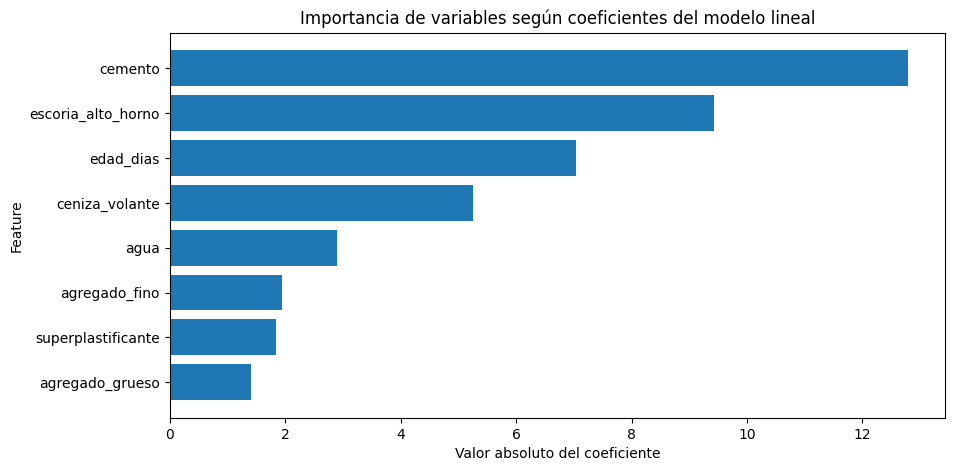

In [25]:
plt.figure(figsize=(10, 5))
plt.barh(coeficientes_importancia["feature"], coeficientes_importancia["coeficiente_abs"])
plt.xlabel("Valor absoluto del coeficiente")
plt.ylabel("Feature")
plt.title("Importancia de variables según coeficientes del modelo lineal")
plt.gca().invert_yaxis()
plt.show()

Las variables más importantes según los coeficientes escalados son cemento, escoria_alto_horno y edad_dias. Todas tienen relación positiva con la resistencia.

La variable agua tiene coeficiente negativo, por lo que mayores valores de agua se asocian con menor resistencia. Como las features están escaladas, los coeficientes pueden compararse entre sí.


## 6. **Reflexión**  
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?  
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?  



## Resolución:

Según el modelo, las variables** más importantes son cemento, escoria_alto_horno y edad_dias, ya que tienen los coeficientes absolutos más altos.** También se destaca agua, pero con relación negativa: a mayor cantidad de agua, menor resistencia estimada.

Esto coincide parcialmente con el análisis exploratorio. En el EDA ya se observaba que cemento, edad_dias y agua tenían una relación visible con la resistencia. En cambio, escoria_alto_horno no mostraba una relación tan clara visualmente, pero el modelo le asignó un peso importante al considerar todas las variables juntas.

El rendimiento del modelo es moderado. El R² cercano a 0.61–0.63 indica que explica una parte importante de la variabilidad, pero no toda. El MAE cercano a 8 MPa muestra que el error promedio todavía es considerable. **Esto puede deberse a que la relación entre los componentes del hormigón y su resistencia no es completamente lineal.**


## **Bonus**:  
- Prueben eliminar variables "poco importantes" y reentrenar el modelo. ¿Mejora el rendimiento?  

# Volvemos a escalar y entrenar el modelo ya con las variables eliminadas.

**Eliminamos las 3 variables del modelo que tienen menos importancia: "agregado_grueso", "superplastificante", "agregado_fino"**

In [26]:
features_eliminar = ["agregado_grueso", "superplastificante", "agregado_fino"]

X_train_red = X_train.drop(columns=features_eliminar)
X_test_red = X_test.drop(columns=features_eliminar)

In [27]:
scaler_red = StandardScaler()

X_train_red_scaled = scaler_red.fit_transform(X_train_red)
X_test_red_scaled = scaler_red.transform(X_test_red)

In [28]:
modelo_lr_red = LinearRegression()

modelo_lr_red.fit(X_train_red_scaled, y_train)

LinearRegression()

In [29]:
y_train_pred_red = modelo_lr_red.predict(X_train_red_scaled)
y_test_pred_red = modelo_lr_red.predict(X_test_red_scaled)

In [31]:
metricas_red = {
    "Train": {
        "R2": r2_score(y_train, y_train_pred_red),
        "MSE": mean_squared_error(y_train, y_train_pred_red),
        "MAE": mean_absolute_error(y_train, y_train_pred_red)
    },
    "Test": {
        "R2": r2_score(y_test, y_test_pred_red),
        "MSE": mean_squared_error(y_test, y_test_pred_red),
        "MAE": mean_absolute_error(y_test, y_test_pred_red)
    }
}

metricas_red_df = pd.DataFrame(metricas_red).T
metricas_red_df

,R2,MSE,MAE
Train,0.604500,112.354722,8.424502
Test,0.630125,95.309814,7.698502


In [32]:
comparacion = pd.concat(
    {
        "Modelo original": metricas_df,
        "Modelo reducido": metricas_red_df
    }
)

comparacion

R2         MSE       MAE
Modelo original Train  0.610459  110.661771  8.330946
                Test   0.627542   95.975484  7.745393
Modelo reducido Train  0.604500  112.354722  8.424502
                Test   0.630125   95.309814  7.698502

# Conclusión

**Al eliminar las variables con menor peso, el rendimiento del modelo se mantuvo muy similar**. En test, el modelo reducido obtuvo un R² levemente mayor y errores MSE/MAE apenas menores, pero la diferencia es mínima.

Esto indica que las variables eliminadas aportaban poca información al modelo lineal. Sin embargo, como la mejora no es significativa, ambos modelos tienen un desempeño muy parecido. El modelo reducido podría preferirse por ser más simple.


---

### **Tips**:  
- Si el R² es muy bajo, revisen si hay relaciones no lineales (y consideren transformar features).  
- Documenten cada paso: ¡la trazabilidad es clave en ciencia de datos!  
- Al final de su trabajo debe crear un apartado de REFERENCIAS para citar todo recurso utilizado. Si usó IA, debe


# Referencias

* Yeh, I. (1998). **Concrete Compressive Strength** [Dataset]. UCI Machine Learning Repository. [https://doi.org/10.24432/C5PK67](https://doi.org/10.24432/C5PK67). ([UCI Aprendizaje Automático][1])

* Scikit-learn. **train_test_split**. Documentación oficial de scikit-learn. ([Scikit-learn][2])

* Scikit-learn. **StandardScaler**. Documentación oficial de scikit-learn.

* Scikit-learn. **LinearRegression**. Documentación oficial de scikit-learn. ([Scikit-learn][3])

* Scikit-learn. **Métricas de regresión: R², MSE y MAE**. Documentación oficial de scikit-learn. ([Scikit-learn][4])

[1]: https://archive.ics.uci.edu/ml/datasets/concrete%2Bcompressive%2Bstrength?utm_source=chatgpt.com "Concrete Compressive Strength"
[2]: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html?utm_source=chatgpt.com "train_test_split — scikit-learn 1.8.0 documentation"
[3]: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html?utm_source=chatgpt.com "LinearRegression — scikit-learn 1.8.0 documentation"
[4]: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html?utm_source=chatgpt.com "r2_score — scikit-learn 1.8.0 documentation"
